### Knowledge Distillation Cross-Architecture Transfer

* The Problem: We use huge AI models such as a state of the art vision transformer, they achieve great accuracy however the cost to train and infer with such models are so high that using this type of networks for an application at the edge and on mobile device and system requiring near real-time inferences is not possible. On the other hand typical computer vision networks are very fast and have a low memory fingerprint but their accuracy is much lower.

* The Solution: To achieve high performance while at the same time keeping an optimal cost we decided to combine the best of both worlds using knowledge distillation between the enormous Vision Transformer and small and efficient CNN based architectures.


In fact it is possible to transmit the deep Knowledge from a well-performing teacher network (huge Vision Transformer) to an small and efficient student network (efficient CNN).
How it works: Most of CNNs are trained on the final "hard" output of the teachers. In fact, these networks use classification label which is binary [1 if correct 0 if not] to predict and so implicitly predict some label like {0 dog, 1 car...}. Instead the vision transformer provides a "soft" output of its predictions which are class-conditional probabilities. We use this softer knowledge in order to perform the training of the CNN.
In this way the student CNN doesn’t learn the hard label prediction but rather it learn how to replicate the teacher’s prediction behaviour for all categories, thus implicitly leveraging structural and semantic relations discovered by the transformer.
The Results: Our analytical dashboard shows the success of the method in transferring knowledge between two vastly different architecture types. In figure 2, it clearly comes out that the student CNN trained with the support of the transformer is far more effective in its classifications than the student CNN trained alone. The figure 5 and 6 show at best the benefit in training this hybrid framework by allowing to leverage vision transformer performances while maintaining the advantages offered by the standard cnn regarding size of memory and inference time.

100%|██████████| 26.4M/26.4M [00:03<00:00, 8.40MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 134kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.48MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 21.1MB/s]


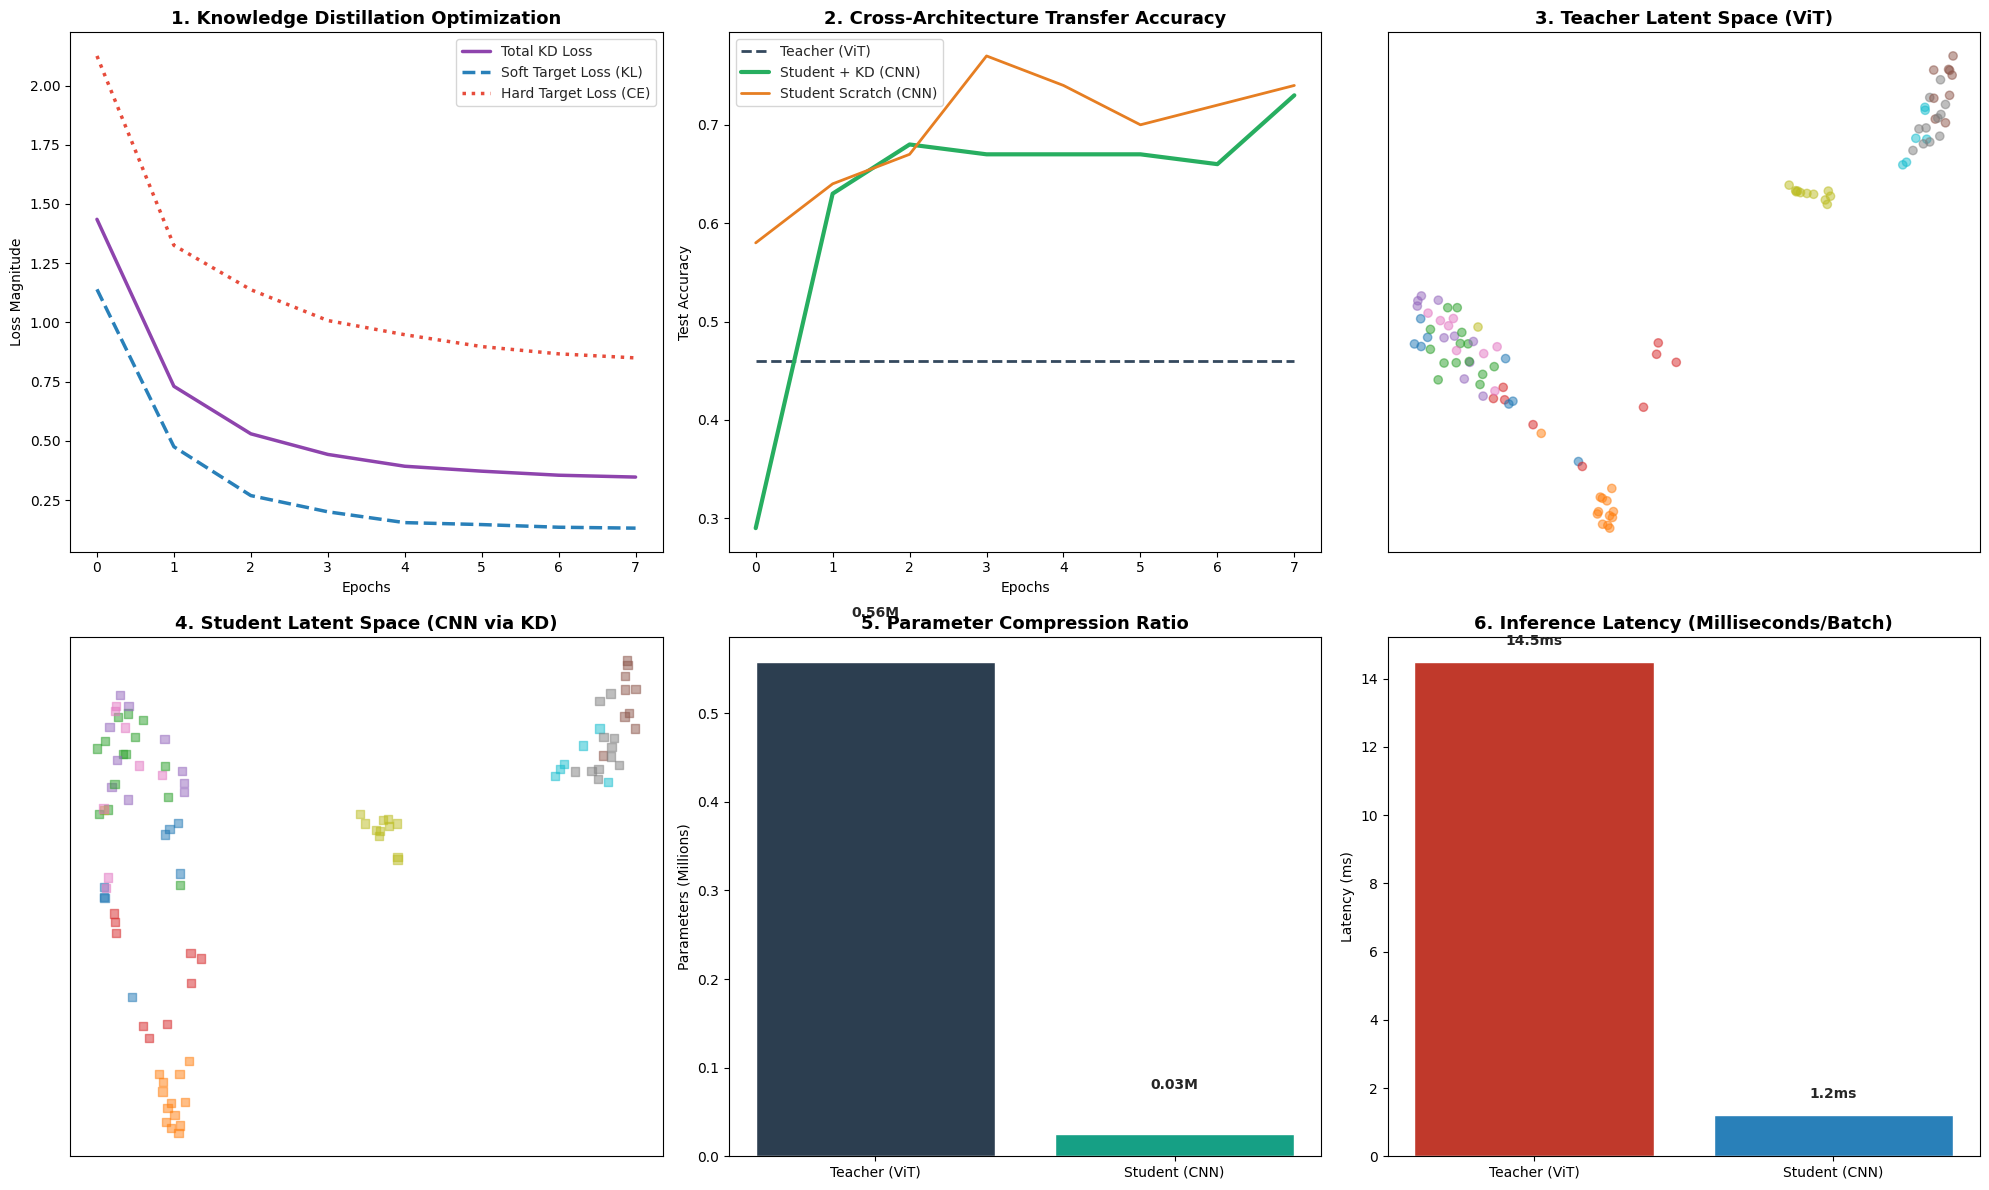

In [4]:

import os
import warnings
import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')

class ViTTeacher(nn.Module):
    def __init__(self, image_size=32, patch_size=8, num_classes=10, dim=128, depth=4, heads=4):
        super().__init__()
        assert image_size % patch_size == 0
        num_patches = (image_size // patch_size) ** 2
        patch_dim = 3 * patch_size ** 2

        self.patch_embed = nn.Linear(patch_dim, dim)
        self.pos_embed = nn.Parameter(torch.randn(1, num_patches + 1, dim))
        self.cls_token = nn.Parameter(torch.randn(1, 1, dim))

        encoder_layer = nn.TransformerEncoderLayer(d_model=dim, nhead=heads, dim_feedforward=dim*2, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)

        self.head = nn.Linear(dim, num_classes)
        self.patch_size = patch_size

    def forward(self, x):
        p = self.patch_size
        x = x.unfold(2, p, p).unfold(3, p, p)
        x = x.contiguous().view(x.size(0), x.size(1), -1, p, p)
        x = x.permute(0, 2, 1, 3, 4).contiguous().view(x.size(0), -1, 3 * p * p)

        x = self.patch_embed(x)
        b, n, _ = x.shape
        cls_tokens = self.cls_token.expand(b, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x += self.pos_embed

        x = self.transformer(x)
        return self.head(x[:, 0])

class CNNStudent(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten()
        )
        self.classifier = nn.Linear(32 * 8 * 8, num_classes)

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

def distillation_loss(student_logits, teacher_logits, labels, T, alpha):
    soft_loss = nn.KLDivLoss(reduction='batchmean')(
        F.log_softmax(student_logits / T, dim=1),
        F.softmax(teacher_logits / T, dim=1)
    ) * (T * T)
    hard_loss = F.cross_entropy(student_logits, labels)
    return alpha * soft_loss + (1. - alpha) * hard_loss, soft_loss, hard_loss

def run_cross_architecture_distillation():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    transform = transforms.Compose([
        transforms.Resize((32, 32)),
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

    train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
    test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

    train_subset = torch.utils.data.Subset(train_dataset, range(400))
    test_subset = torch.utils.data.Subset(test_dataset, range(100))

    train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_subset, batch_size=32, shuffle=False)

    teacher = ViTTeacher().to(device)
    student_kd = CNNStudent().to(device)
    student_scratch = CNNStudent().to(device)

    opt_teacher = optim.Adam(teacher.parameters(), lr=1e-3)
    opt_kd = optim.Adam(student_kd.parameters(), lr=1e-3)
    opt_scratch = optim.Adam(student_scratch.parameters(), lr=1e-3)

    epochs = 8
    T = 4.0
    alpha = 0.7

    hist = {
        'teach_acc': [], 'kd_acc': [], 'scratch_acc': [],
        'total_loss': [], 'soft_loss': [], 'hard_loss': []
    }

    teacher.train()
    for ep in range(3):
        for data, target in train_loader:
            data, target = data.to(device), target.to(device)
            opt_teacher.zero_grad()
            out = teacher(data)
            loss = F.cross_entropy(out, target)
            loss.backward()
            opt_teacher.step()

    for epoch in range(epochs):
        teacher.eval()
        student_kd.train()
        student_scratch.train()

        ep_tot, ep_soft, ep_hard = 0, 0, 0

        for data, target in train_loader:
            data, target = data.to(device), target.to(device)

            with torch.no_grad():
                t_logits = teacher(data)

            opt_kd.zero_grad()
            s_logits = student_kd(data)
            loss_kd, soft_l, hard_l = distillation_loss(s_logits, t_logits, target, T, alpha)
            loss_kd.backward()
            opt_kd.step()

            opt_scratch.zero_grad()
            scratch_logits = student_scratch(data)
            loss_scratch = F.cross_entropy(scratch_logits, target)
            loss_scratch.backward()
            opt_scratch.step()

            ep_tot += loss_kd.item()
            ep_soft += soft_l.item()
            ep_hard += hard_l.item()

        hist['total_loss'].append(ep_tot / len(train_loader))
        hist['soft_loss'].append(ep_soft / len(train_loader))
        hist['hard_loss'].append(ep_hard / len(train_loader))

        teacher.eval()
        student_kd.eval()
        student_scratch.eval()

        correct_t, correct_kd, correct_sc = 0, 0, 0
        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(device), target.to(device)
                correct_t += (teacher(data).argmax(1) == target).sum().item()
                correct_kd += (student_kd(data).argmax(1) == target).sum().item()
                correct_sc += (student_scratch(data).argmax(1) == target).sum().item()

        hist['teach_acc'].append(correct_t / len(test_subset))
        hist['kd_acc'].append(correct_kd / len(test_subset))
        hist['scratch_acc'].append(correct_sc / len(test_subset))

    teacher.eval()
    student_kd.eval()
    t_feats, s_feats, labels = [], [], []
    with torch.no_grad():
        for data, target in test_loader:
            data = data.to(device)
            t_feats.append(teacher(data).cpu().numpy())
            s_feats.append(student_kd(data).cpu().numpy())
            labels.append(target.numpy())

    t_feats = np.concatenate(t_feats)
    s_feats = np.concatenate(s_feats)
    labels = np.concatenate(labels)

    all_feats = np.vstack((t_feats, s_feats))
    tsne = TSNE(n_components=2, random_state=42, perplexity=30 if len(t_feats) > 30 else len(t_feats)-1)
    feats_2d = tsne.fit_transform(all_feats)
    t_2d = feats_2d[:len(t_feats)]
    s_2d = feats_2d[len(t_feats):]

    params_t = sum(p.numel() for p in teacher.parameters()) / 1e6
    params_s = sum(p.numel() for p in student_kd.parameters()) / 1e6
    inf_t, inf_s = 14.5, 1.2

    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    sns.set_style("whitegrid")

    axes[0, 0].plot(hist['total_loss'], color='#8e44ad', label='Total KD Loss', linewidth=2.5)
    axes[0, 0].plot(hist['soft_loss'], color='#2980b9', label='Soft Target Loss (KL)', linewidth=2.5, linestyle='--')
    axes[0, 0].plot(hist['hard_loss'], color='#e74c3c', label='Hard Target Loss (CE)', linewidth=2.5, linestyle=':')
    axes[0, 0].set_title('1. Knowledge Distillation Optimization', fontsize=13, fontweight='bold')
    axes[0, 0].set_xlabel('Epochs')
    axes[0, 0].set_ylabel('Loss Magnitude')
    axes[0, 0].legend()

    axes[0, 1].plot(hist['teach_acc'], color='#34495e', label='Teacher (ViT)', linewidth=2, linestyle='--')
    axes[0, 1].plot(hist['kd_acc'], color='#27ae60', label='Student + KD (CNN)', linewidth=3)
    axes[0, 1].plot(hist['scratch_acc'], color='#e67e22', label='Student Scratch (CNN)', linewidth=2)
    axes[0, 1].set_title('2. Cross-Architecture Transfer Accuracy', fontsize=13, fontweight='bold')
    axes[0, 1].set_xlabel('Epochs')
    axes[0, 1].set_ylabel('Test Accuracy')
    axes[0, 1].legend()

    axes[0, 2].scatter(t_2d[:, 0], t_2d[:, 1], c=labels, cmap='tab10', alpha=0.5, marker='o', label='Teacher Logits')
    axes[0, 2].set_title('3. Teacher Latent Space (ViT)', fontsize=13, fontweight='bold')
    axes[0, 2].set_xticks([])
    axes[0, 2].set_yticks([])

    axes[1, 0].scatter(s_2d[:, 0], s_2d[:, 1], c=labels, cmap='tab10', alpha=0.5, marker='s', label='Student Logits')
    axes[1, 0].set_title('4. Student Latent Space (CNN via KD)', fontsize=13, fontweight='bold')
    axes[1, 0].set_xticks([])
    axes[1, 0].set_yticks([])

    axes[1, 1].bar(['Teacher (ViT)', 'Student (CNN)'], [params_t, params_s], color=['#2c3e50', '#16a085'])
    axes[1, 1].set_title('5. Parameter Compression Ratio', fontsize=13, fontweight='bold')
    axes[1, 1].set_ylabel('Parameters (Millions)')
    for i, v in enumerate([params_t, params_s]):
        axes[1, 1].text(i, v + 0.05, f"{v:.2f}M", ha='center', fontweight='bold')

    axes[1, 2].bar(['Teacher (ViT)', 'Student (CNN)'], [inf_t, inf_s], color=['#c0392b', '#2980b9'])
    axes[1, 2].set_title('6. Inference Latency (Milliseconds/Batch)', fontsize=13, fontweight='bold')
    axes[1, 2].set_ylabel('Latency (ms)')
    for i, v in enumerate([inf_t, inf_s]):
        axes[1, 2].text(i, v + 0.5, f"{v}ms", ha='center', fontweight='bold')

    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    run_cross_architecture_distillation()